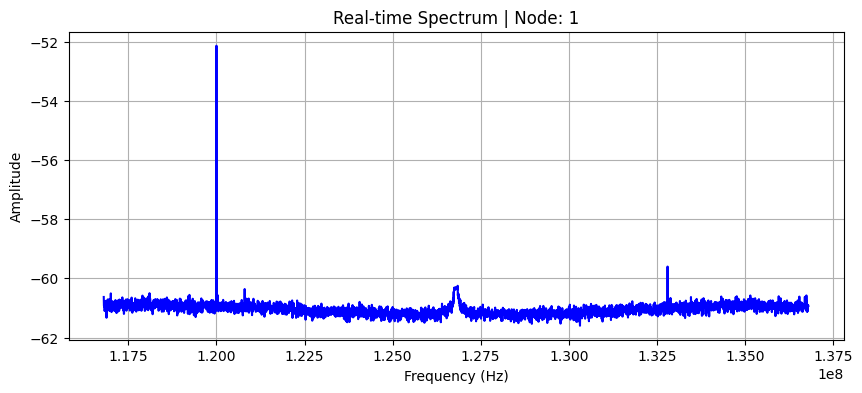

[IPYKERNEL_LAUNCHER]INFO      Fetching realtime signal for Node 1 (MAC: d8:3a:dd:f7:1d:f2)
[IPYKERNEL_LAUNCHER]INFO      Fetching realtime signal for Node 1 (MAC: d8:3a:dd:f7:1d:f2)


KeyboardInterrupt: 

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# Real-time spectrum monitor for a single SDR node
#
# TUTORIAL
# ────────
# 1. cfg  ──  loads your .env file (API_URL, DEBUG, VERBOSE, …) and sets up the
#             shared logger.  Always import it first; every other module uses it.
#
# 2. DataRequest  ──  the HTTP client for the ANE RSM API.
#    Constructor args:
#        log      : the logger returned by cfg.set_logger()
#        base_url : the root URL of the API (read from cfg.API_URL)
#
# 3. dr.get_realtime_signal(node_id)  ──  fetches the latest PSD snapshot for
#    the node identified by `node_id` (integer).  Returns a RealtimeSignal
#    dataclass with the fields:
#        .pxx            : numpy array of power values in dBm
#        .start_freq_hz  : lowest frequency bin in Hz
#        .end_freq_hz    : highest frequency bin in Hz
#        .mac            : sensor MAC address
#
# 4. The loop runs until you interrupt the kernel (▪ Stop button or Ctrl+C).
#    It only redraws the plot when the PSD vector has actually changed,
#    saving CPU and avoiding unnecessary flicker.
# ─────────────────────────────────────────────────────────────────────────────

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from libs.data_request import DataRequest
import cfg

# Build the shared logger (respects DEBUG / VERBOSE env flags from .env)
log = cfg.set_logger()

# ── Step 1: Create the API client ────────────────────────────────────────────
# base_url is read from the API_URL variable in your .env file.
dr = DataRequest(log=log, base_url=cfg.API_URL)

# ── Step 2: Choose which node to monitor ─────────────────────────────────────
# Change node_id to the integer ID of any node registered in the system.
node_id = 1

# Keeps a copy of the last PSD vector so we can skip unchanged frames.
last_pxx = None

# ── Step 3: Polling loop ──────────────────────────────────────────────────────
# The cell runs indefinitely.  Stop it from the kernel toolbar when finished.
while True:
    # Fetch the latest snapshot from the API
    signal = dr.get_realtime_signal(node_id)

    # Only refresh the plot when the spectrum has actually changed.
    # np.array_equal does an element-wise comparison, so even a tiny variation
    # in any bin triggers a redraw.
    if last_pxx is None or not np.array_equal(last_pxx, signal.pxx):
        last_pxx = signal.pxx.copy()

        # Build a frequency axis that spans [start_freq_hz, end_freq_hz]
        # with one point per PSD bin.
        freqs = np.linspace(signal.start_freq_hz, signal.end_freq_hz, len(signal.pxx))

        # clear_output(wait=True) removes the previous figure before drawing
        # the new one, giving a smooth "live update" effect.
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.plot(freqs, signal.pxx, color='blue')
        plt.title(f"Real-time Spectrum | Node: {node_id}")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.show()

    # Wait 1 second before polling again.  Lower this value for faster updates
    # at the cost of higher API load.
    time.sleep(1)
